# Trabajo Practico 3
## Visión de Computadora I

### Integrantes 
* Lucia T. Capon Paul
* Cesar Orellana
* Madrid, Martin
* Leandro Britez


### Ejercicios : 

Encontrar el logotipo de la gaseosa dentro de las imágenes provistas en `Material_TPs/TP3/`images a partir del template `Material_TPs/TP3/template`

1. Obtener una detección del logo en cada imagen sin falsos positivos

2. Plantear y validar un algoritmo para múltiples detecciones en la imagen coca_multi.png con el mismo témplate del ítem 1.

3. Generalizar el algoritmo del item 2 para todas las imágenes. 

Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza
de la detección.

Imagen: coca_logo_1.png | Max Score: 0.2536


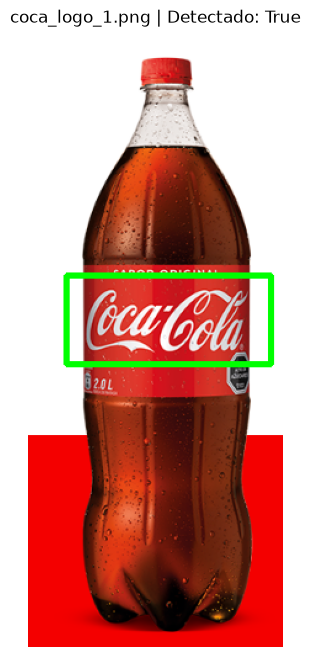

Imagen: coca_logo_2.png | Max Score: 0.1355


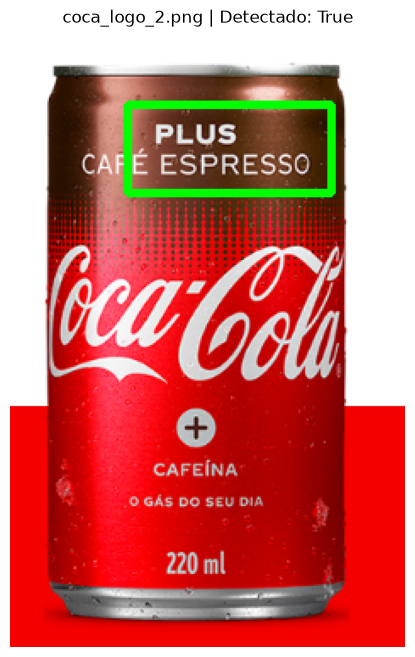

Imagen: coca_multi.png | Max Score: 0.1287


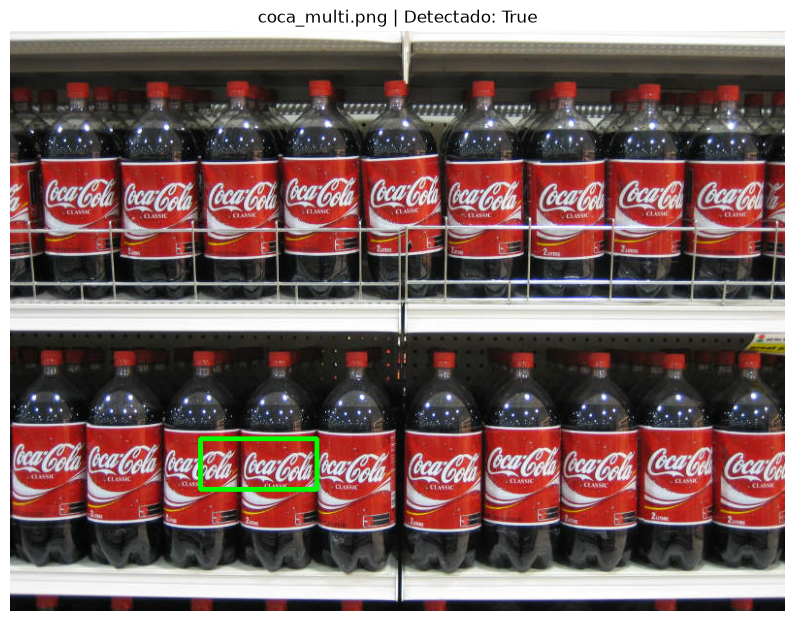

Imagen: coca_retro_1.png | Max Score: 0.1152


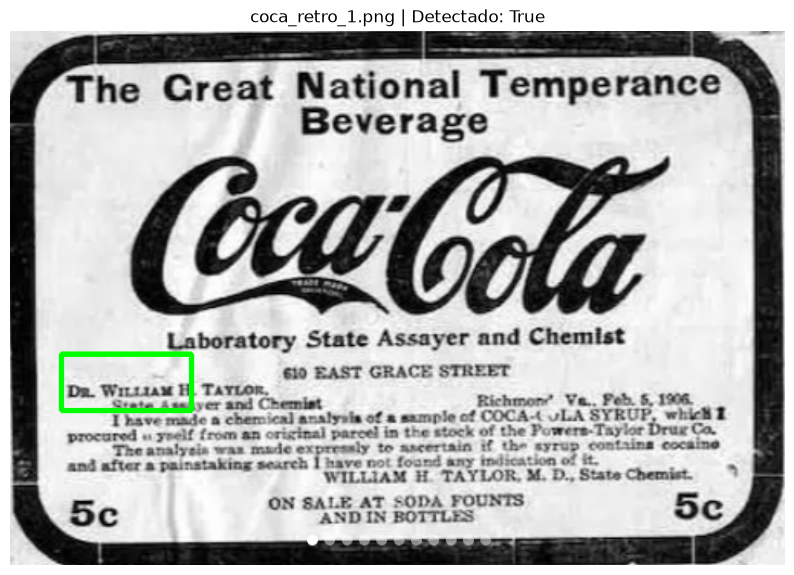

Imagen: coca_retro_2.png | Max Score: 0.2190


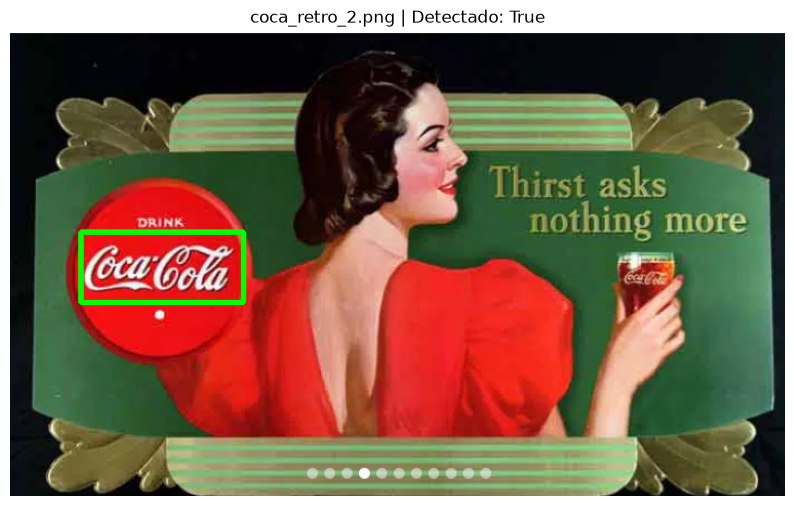

Imagen: COCA-COLA-LOGO.jpg | Max Score: 0.1272


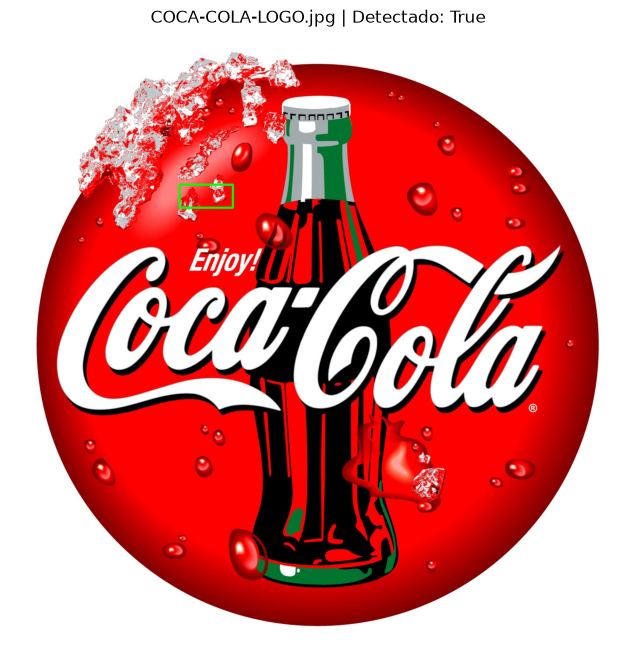

Imagen: logo_1.png | Max Score: 0.1241


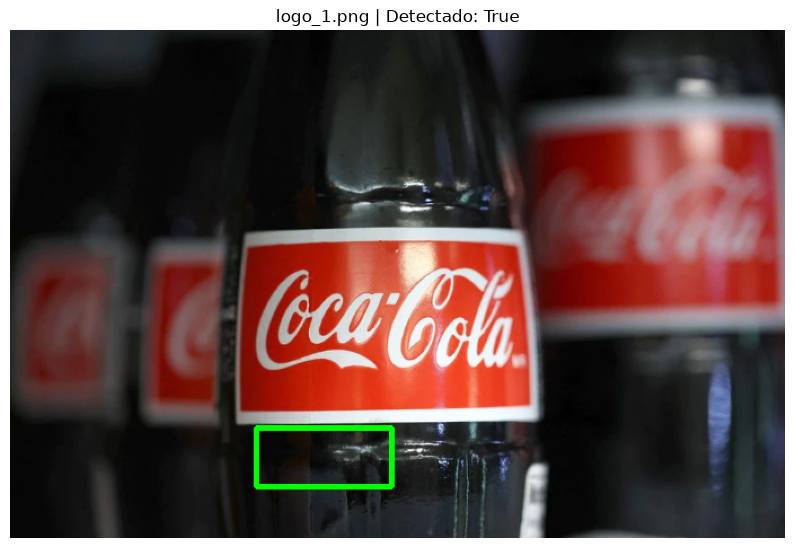

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Utilidades
# =====================================================
def load_image(path):
    img = cv2.imread(path)
    if img is None: raise ValueError(f"No se pudo cargar: {path}")
    return img

def resize_image(img, new_w, new_h):
    return cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

# =====================================================
# Algoritmo 
# =====================================================
def detectar_logo_mejor_resultado(imagen_path, template_path, threshold=0.30): # Bajé el threshold a 0.30
    img = load_image(imagen_path)
    template = load_image(template_path)

    # Preparamos una lista de "fuentes de búsqueda"
    # 1. Canal azul de la imagen
    # 2. Imagen completa en escala de grises (fallback)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.equalizeHist(img_gray) # IMPORTANTE: Ecualizamos para mejorar contraste
    
    b_img, _, _ = cv2.split(img)
    
    # Fuentes a probar
    fuentes_a_buscar = [b_img, img_gray]
    
    b_tmp, _, _ = cv2.split(template)
    tmp_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)
    
    mejor_score_global = -1
    mejor_rect = None

    # Ampliamos el rango de escalas (A veces la botella está muy lejos)
    scales = np.linspace(0.1, 2.5, 60)
    angulos = [-45, -22, 0, 22, 45]

    for src in fuentes_a_buscar:
        for tmp_proc in [b_tmp, cv2.bitwise_not(b_tmp)]: # Original e Invertido
            for angulo in angulos:
                # Rotar el template
                rows, cols = tmp_proc.shape
                M = cv2.getRotationMatrix2D((cols/2, rows/2), angulo, 1.0)
                tmp_rot = cv2.warpAffine(tmp_proc, M, (cols, rows))
                for scale in scales:
                    new_w = int(tmp_rot.shape[1] * scale)
                    new_h = int(tmp_rot.shape[0] * scale)

                    if new_h > src.shape[0] or new_w > src.shape[1]: continue
                    
                    tmp_resized = resize_image(tmp_proc, new_w, new_h)
                    res = cv2.matchTemplate(src, tmp_resized, cv2.TM_CCOEFF_NORMED)
                    _, max_val, _, max_loc = cv2.minMaxLoc(res)

                    if max_val > mejor_score_global:
                        mejor_score_global = max_val
                        mejor_rect = (max_loc[0], max_loc[1], new_w, new_h)

    # Resultado final
    resultado = img.copy()
    detectado = False
    if mejor_score_global >= threshold:
        x, y, w, h = mejor_rect
        cv2.rectangle(resultado, (x, y), (x + w, y + h), (0, 255, 0), 3)
        detectado = True
        print(f"Detectado con score: {mejor_score_global:.2f}")
    else:
        print(f"FALLO: El mejor score fue {mejor_score_global:.2f}. Ajusta el threshold.")

    return resultado, detectado


# =====================================================
# Ejecución
# =====================================================
images_detection = [
    "coca_logo_1.png",
    "coca_logo_2.png",
    "coca_multi.png", # Nota: Aquí solo marcará el "mejor" detectado
    "coca_retro_1.png",
    "coca_retro_2.png",
    "COCA-COLA-LOGO.jpg",
    "logo_1.png",
]

for image_name in images_detection:
    # Ajusta la ruta a tu carpeta de imágenes
    resultado, detectado = detectar_logo_mejor_resultado(
        imagen_path=f"images/{image_name}",
        template_path="template/pattern.png",
        threshold=0.05
    )

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    plt.title(f"{image_name} | Detectado: {detectado}")
    plt.axis("off")
    plt.show()